In [2]:
!pip install seaborn matplotlib

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


FAKEDDIT DATASET OVERVIEW

Total samples: 564,000

Columns: ['author', 'clean_title', 'created_utc', 'domain', 'hasImage', 'id', 'image_url', 'linked_submission_id', 'num_comments', 'score', 'subreddit', 'title', 'upvote_ratio', '2_way_label', '3_way_label', '6_way_label']

Dataset shape: (564000, 16)

SAMPLE DATA
           author                                        clean_title  \
0     Alexithymia  my walgreens offbrand mucinex was engraved wit...   
1        VIDCAs17                this concerned sink with a tiny hat   
2  prometheus1123      hackers leak emails from uae ambassador to us   
3             NaN                           puppy taking in the view   
4       3rikR3ith               i found a face in my sheet music too   

    created_utc         domain  hasImage      id  \
0  1.551641e+09    i.imgur.com      True  awxhir   
1  1.534727e+09      i.redd.it      True  98pbid   
2  1.496511e+09  aljazeera.com      True  6f2cy5   
3  1.471341e+09    i.imgur.com      True  4

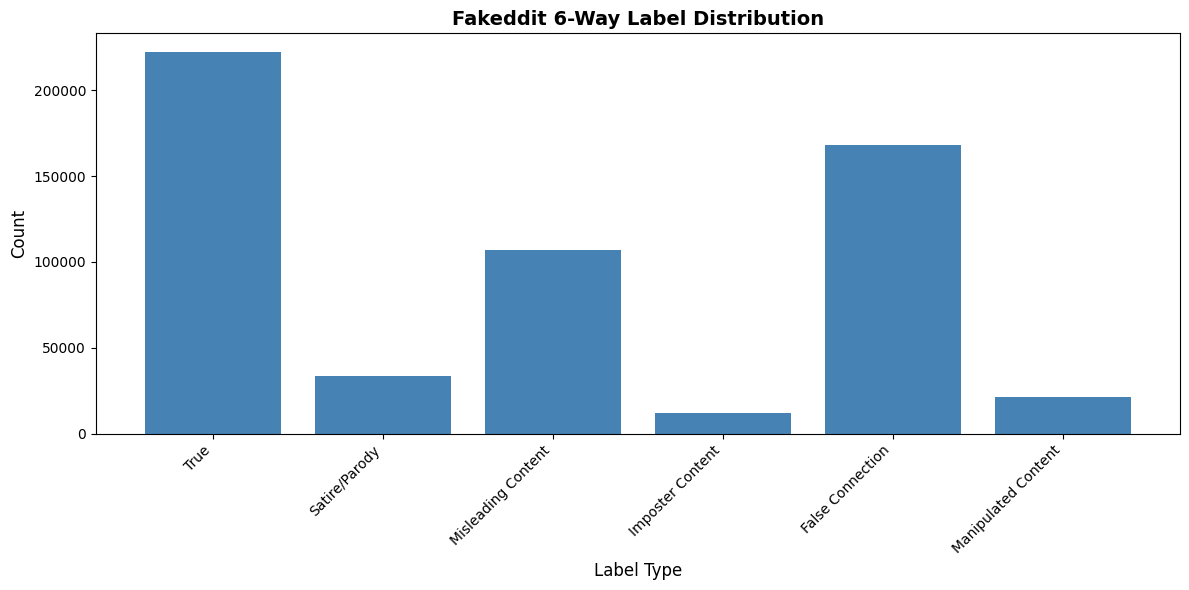


✅ Samples with images: 564,000 (100.00%)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the training data
train_df = pd.read_csv('../data/raw/train.tsv', sep='\t')

# Display basic info
print("="*60)
print("FAKEDDIT DATASET OVERVIEW")
print("="*60)
print(f"\nTotal samples: {len(train_df):,}")
print(f"\nColumns: {list(train_df.columns)}")
print(f"\nDataset shape: {train_df.shape}")

# Show first few rows
print("\n" + "="*60)
print("SAMPLE DATA")
print("="*60)
print(train_df.head())

# Label distribution
print("\n" + "="*60)
print("LABEL DISTRIBUTION (6-way classification)")
print("="*60)
label_counts = train_df['6_way_label'].value_counts().sort_index()

# Label meanings
label_names = {
    0: "True",
    1: "Satire/Parody", 
    2: "Misleading Content",
    3: "Imposter Content",
    4: "False Connection",
    5: "Manipulated Content"
}

print("\nLabel meanings:")
for label, name in label_names.items():
    count = label_counts.get(label, 0)
    percentage = (count / len(train_df)) * 100
    print(f"  {label}: {name:25s} - {count:6,} samples ({percentage:5.2f}%)")

# Visualize
plt.figure(figsize=(12, 6))
labels = [label_names[i] for i in sorted(label_names.keys())]
counts = [label_counts.get(i, 0) for i in sorted(label_names.keys())]
plt.bar(labels, counts, color='steelblue')
plt.xlabel('Label Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Fakeddit 6-Way Label Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\n✅ Samples with images: {train_df['hasImage'].sum():,} ({(train_df['hasImage'].sum()/len(train_df)*100):.2f}%)")